In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ANÁLISE EXPLORATÓRIA DE DADOS:

In [4]:
df = pd.read_csv('manutencao_preditiva.csv')

In [7]:
#Dimensoes do dataset:
num_linhas, num_colunas = df.shape
print(f"O dataset possui {num_linhas} linhas e {num_colunas} colunas.")

O dataset possui 10000 linhas e 14 colunas.


In [8]:
# Tipos de dados das variáveis:

display(df.dtypes)
print("Tipos de dados das variáveis:")

udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Tipos de dados das variáveis:


In [9]:
#Resumo estatístico das colunas numéricas usando ".describe()":
display(df.describe())
print("Resumo estatístico descritivo:")


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Resumo estatístico descritivo:


ANÁLISE GRÁFICA:

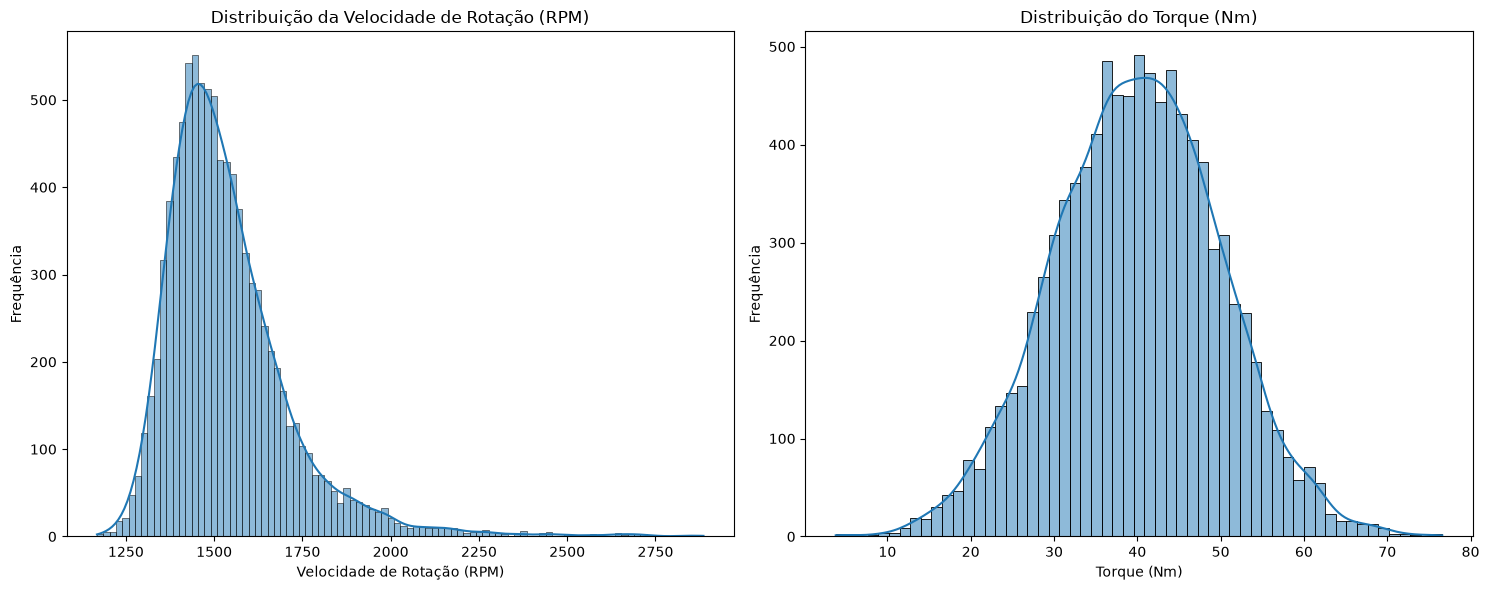

In [13]:
#HISTOGRAMA PARA DEMONSTRAÇÃO DA DISTRIBUIÇÃO DE VARIÁVEIS PREDITORAS:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['velocidade_rotacao_rpm'].dropna(), kde=True)
plt.title('Distribuição da Velocidade de Rotação (RPM)')
plt.xlabel('Velocidade de Rotação (RPM)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.histplot(df['torque_nm'].dropna(), kde=True)
plt.title('Distribuição do Torque (Nm)')
plt.xlabel('Torque (Nm)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

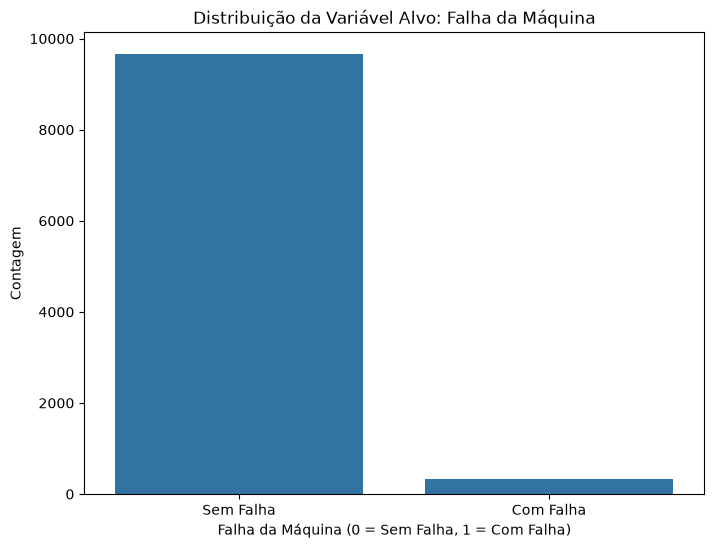

Porcentagem de máquinas sem falha: 96.61%
Porcentagem de máquinas com falha: 3.39%


In [14]:
#GRÁFICO BARRAS PARA DEMONSTRAR O DESBALANCEAMENTO DA VARIÁVEL ALVO:

plt.figure(figsize=(8, 6))
sns.countplot(x='falha_maquina', data=df)
plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Sem Falha, 1 = Com Falha)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Sem Falha', 'Com Falha'])
plt.show()

falha_counts = df['falha_maquina'].value_counts(normalize=True) * 100
print(f"Porcentagem de máquinas sem falha: {falha_counts[0]:.2f}%")
print(f"Porcentagem de máquinas com falha: {falha_counts[1]:.2f}%")

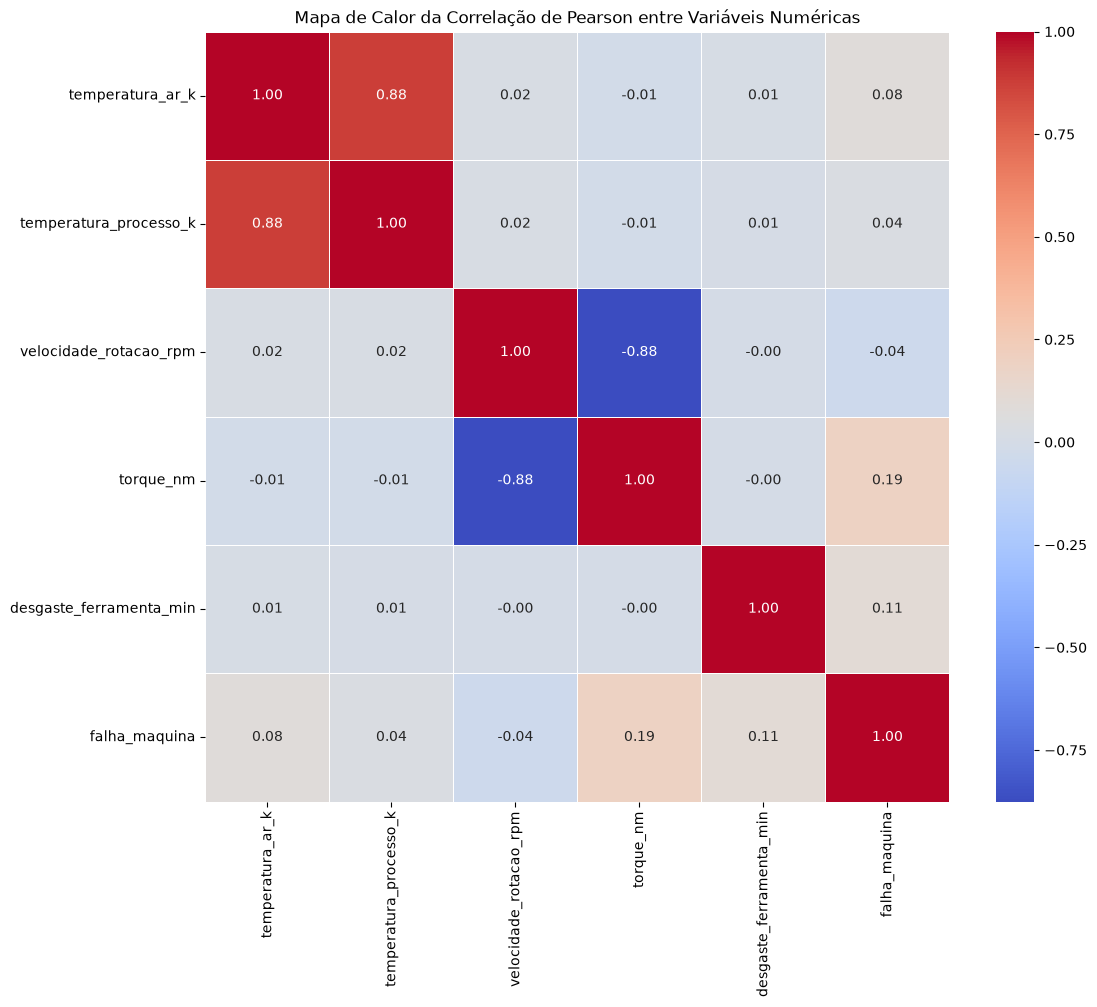

In [16]:
# MAPA DE CALOR - CORRELAÇÃO DE PEARSON:
# Excluídas as colunas de identificação (udi, id_produto) e colunas de falha que não são a variável alvo.

columns_to_exclude = ['udi', 'id_produto', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

df_corr = df.drop(columns=columns_to_exclude, errors='ignore')

# Selecionar apenas colunas numéricas para a correlação
df_numeric = df_corr.select_dtypes(include=['number'])

correlation_matrix = df_numeric.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

Conclusoes sobre os gráficos previamente gerados:
1. As curvas de "sino" mostram a distribuição normal (estatística) de velocidade de rotação e torque com picos em baixa frequencia, como esperado, pois faz sentido que máquinas operem em condições normais, não em extremos, o que certamente causaria maior desgaste e falhas, por consequencia. 
2. O gráfico de barras comprova a estabilidade na operação, com uma taxa de falha abaixo de 5%.
3. Para este modelo, a correlação de Pearson nao traz necessariamente informações relevantes. Começa a mostrar uma relação da variavel alvo com o torque, mas as demais correlações que seriam consideradas importantes por estarem próximas de "1", são óbvias, e não trazem informação relevante.   